In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import torch
import json

sys.path.insert(0, '/workspace')

import experiments.plot_functions as pf

In [2]:
# %config InlineBackend.figure_formats = ['svg']

# Training loss

In [3]:
# training loss history
dict_models_training_history_path = {
    "Encoder": "/workspace/data/checkpoints/encoder_loss_norm_and_cosine_similarity_smoothL1_alpha10.0/cocoDoerig/run_0/training_history.json",
    "LLM-guided AE": "/workspace/data/checkpoints/ae_loss_l2/cocoDoerig/run_0/training_history.json",
    "Standard AE": "/workspace/data/checkpoints/vanilla_ae_loss_l2/cocoDoerig/run_0/training_history.json",
    "Standard VAE": "/workspace/data/checkpoints/vanilla_from_ae_beta_vae_loss_standard_beta0.001_recon_loss_l2/cocoDoerig/run_0/training_history.json",
    "LLM-guided VAE": "/workspace/data/checkpoints/beta_vae_loss_llm_alignment_beta0.001_recon_loss_l2_llm_alignment_loss_cosine_similarity_gamma0.5/cocoDoerig/run_0/training_history.json",
    "LLM-guided VAE (LLM->images)": "/workspace/data/checkpoints/beta_vae_llm_loss_l2_and_img_norm_delta0.1/cocoDoerig/run_0/training_history.json",
    "Decoder (LLM->images)": "/workspace/data/checkpoints/decoder_loss_l2/cocoDoerig/run_0/training_history.json"
}

In [4]:
def plot_history(history_dict, ylabel_dict, legend_loc):

    skip_keys = {"start_epoch", "end_epoch", "alpha", "gamma", "beta"}
    all_keys = [k for k in history_dict if k not in skip_keys]
    base_keys = [k for k in all_keys if not k.startswith("val_")]

    base_keys = base_keys[1:] + base_keys[:1]
    start_epoch = history_dict.get("start_epoch", 1)
    n_epochs = len(history_dict[base_keys[0]])
    epochs = list(range(start_epoch, start_epoch + n_epochs))

    fig, axes = plt.subplots(1, len(base_keys), figsize=(5 * len(base_keys), 4), sharey=False)
    if len(base_keys) == 1:
        axes = [axes]
    print(base_keys)
    for id, (ax, key) in enumerate(zip(axes, base_keys)):
        ylabel = ylabel_dict[key]
        ax.plot(epochs, history_dict[key], label="training")
        val_key = f"val_{key}"
        if val_key in history_dict:
            ax.plot(epochs, history_dict[val_key], label="validation")
        ax.set_ylabel(ylabel, fontsize=22)
        ax.tick_params(axis="both", labelsize=15)
        ax.locator_params(axis="y", nbins=5) 
        ax.set_xlabel("Epoch", fontsize=20)
        if id == 0:
            if legend_loc is None:
                ax.legend(fontsize=20)
                tight_layout = True
            elif legend_loc == "out":
                ax.legend(loc="upper left", fontsize=20, bbox_to_anchor=(1.02, 1.0))
                tight_layout = False

            else:
                ax.legend(loc=legend_loc, fontsize=20)
                tight_layout = True

        ax.grid(True)
    if tight_layout:
        plt.tight_layout()
    plt.show()

Encoder
['cosine_sim_loss', 'norm_loss', 'loss']


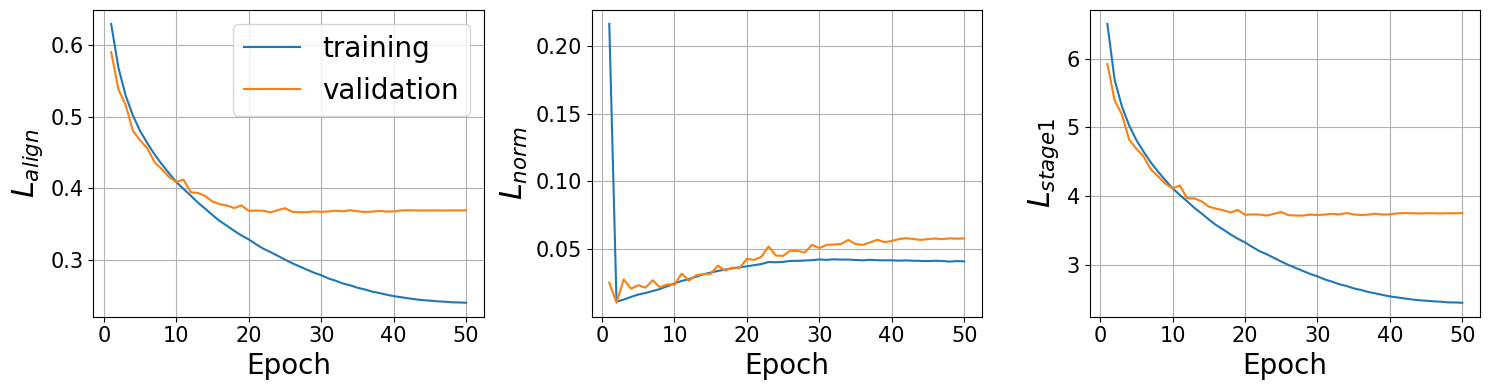

LLM-guided AE
['loss']


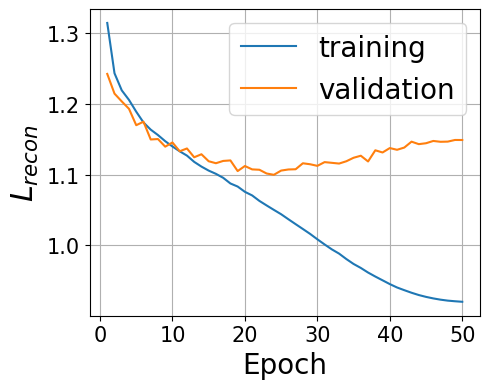

Standard AE
['loss']


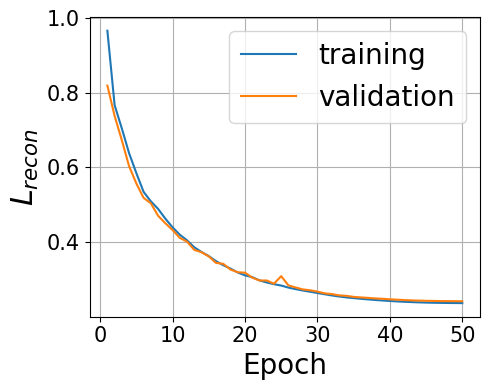

Standard VAE
['recon_loss', 'kl_loss', 'loss']


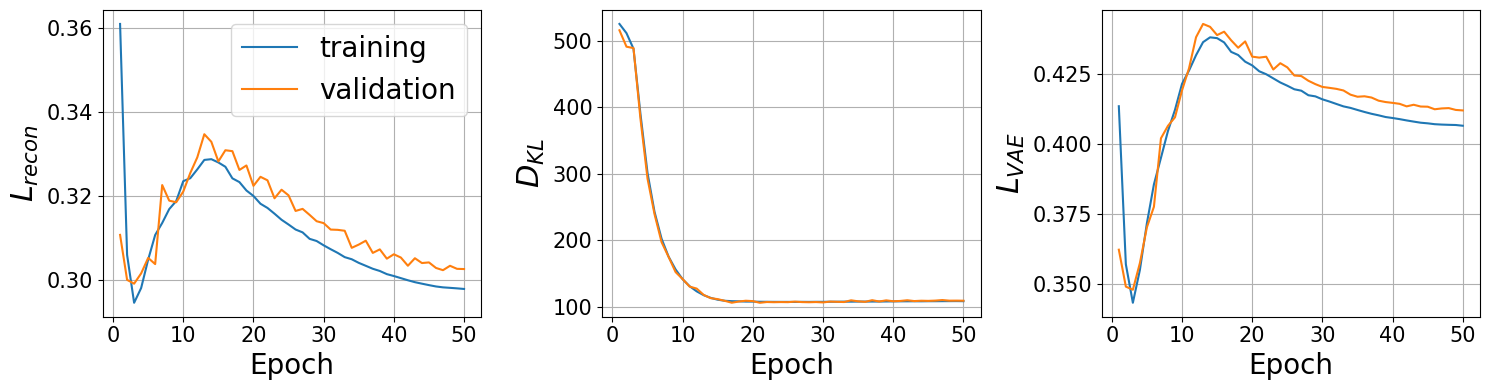

LLM-guided VAE
['recon_loss', 'kl_loss', 'llm_alignment_loss', 'loss']


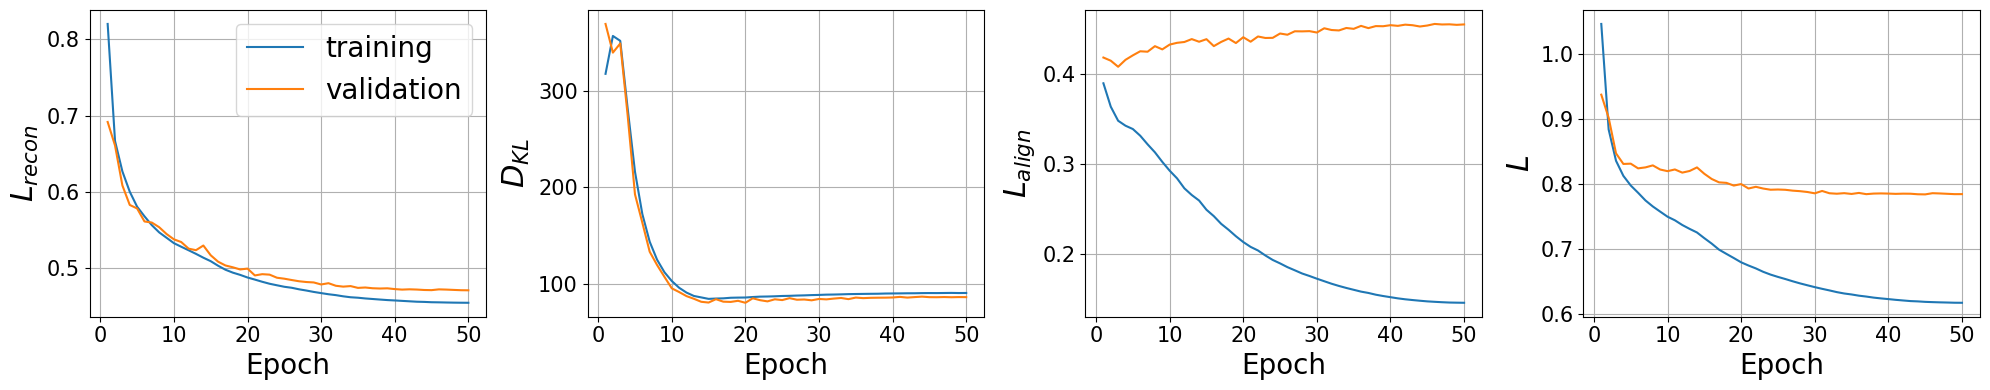

LLM-guided VAE (LLM->images)
['recon_loss', 'norm_loss', 'loss']


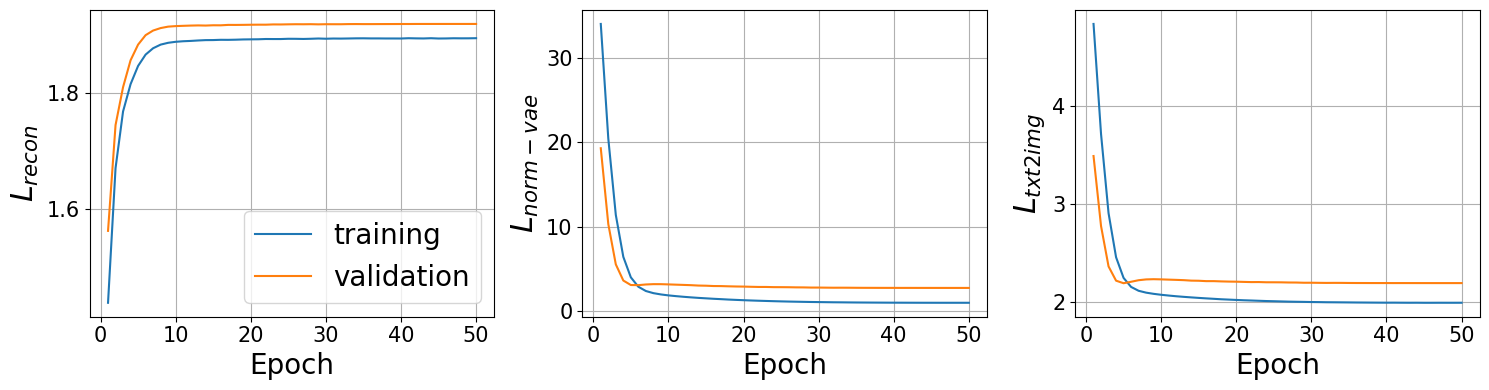

Decoder (LLM->images)
['loss']


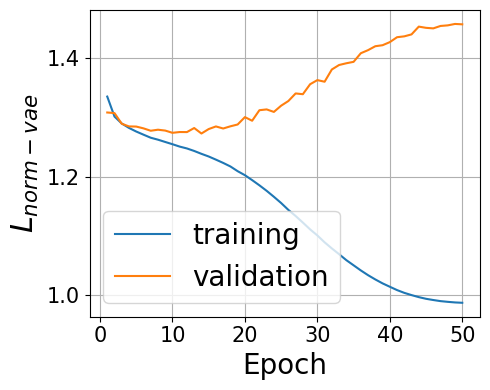

In [12]:
for model_name, history_path in dict_models_training_history_path.items():
    with open(history_path, "r") as f:
        training_history = json.load(f)
    print(model_name)
    legend_loc = None
    if model_name == "Encoder":
        ylabel_dict = {"loss": r"$L_{stage1}$",
                       "cosine_sim_loss": r"$L_{align}$",
                       "norm_loss": r"$L_{norm}$"}
        
    elif model_name in ("LLM-guided AE", "standard AE"):
        ylabel_dict = {"loss": r"$L_{recon}$"}

    elif model_name == "Standard VAE":
        ylabel_dict = {"loss": r"$L_{VAE}$",
                       "recon_loss":  r"$L_{recon}$",
                       "kl_loss": r"$D_{KL}$"}
        
    elif model_name == "LLM-guided VAE":
        ylabel_dict = {"loss": r"$L$",
                       "recon_loss":  r"$L_{recon}$",
                       "llm_alignment_loss": r"$L_{align}$",
                       "kl_loss": r"$D_{KL}$"}
    elif model_name == "LLM-guided VAE (LLM->images)":
        ylabel_dict = {"loss": r"$L_{txt2img}$",
                       "recon_loss":  r"$L_{recon}$",
                       "norm_loss": r"$L_{norm-vae}$"}
    elif model_name == "Decoder (LLM->images)":
        ylabel_dict = {"loss": r"$L_{norm-vae}$"}
        #legend_loc="out"
    plot_history(training_history, ylabel_dict, legend_loc)

# delete the loaded training history to free memory
del training_history

# Evaluation with testing data

## evaluation using the last checkpoint

In [6]:
# testing data
dict_models_evaluation_loss_path = {
    "Standard AE": "/workspace/data/checkpoints/vanilla_ae_loss_l2/cocoDoerig/run_0/evaluation/checkpoint_epoch50/evaluation_loss.json",
    "LLM-guided AE": "/workspace/data/checkpoints/ae_loss_l2/cocoDoerig/run_0/evaluation/checkpoint_epoch25/evaluation_loss.json",
    "Standard VAE": "/workspace/data/checkpoints/vanilla_from_ae_beta_vae_loss_standard_beta0.001_recon_loss_l2/cocoDoerig/run_0/evaluation/checkpoint_epoch50/evaluation_loss.json",
    "LLM-guided VAE": "/workspace/data/checkpoints/beta_vae_loss_llm_alignment_beta0.001_recon_loss_l2_llm_alignment_loss_cosine_similarity_gamma0.5/cocoDoerig/run_0/evaluation/checkpoint_epoch30/evaluation_loss.json"
}

for model_name, evaluation_loss_path in dict_models_evaluation_loss_path.items():
    with open(evaluation_loss_path, "r") as f:
        evaluation_loss = json.load(f)

    print(f"{model_name}: {evaluation_loss}")


Standard AE: {'loss': 0.23496094077253996}
LLM-guided AE: {'loss': 1.0849486517318307}
Standard VAE: {'loss': 0.400263879361218, 'recon_loss': 0.2946473739571767, 'kl_loss': 105.61650037540801}
LLM-guided VAE: {'loss': 0.7640709223812574, 'recon_loss': 0.4611280245421684, 'kl_loss': 83.76238896367322, 'llm_alignment_loss': 0.4383610127135499}


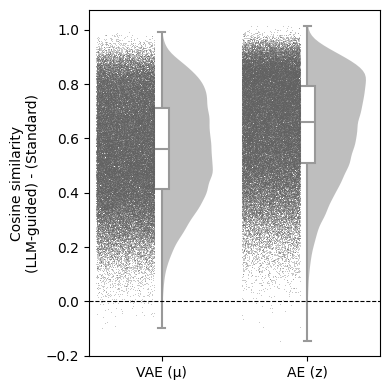

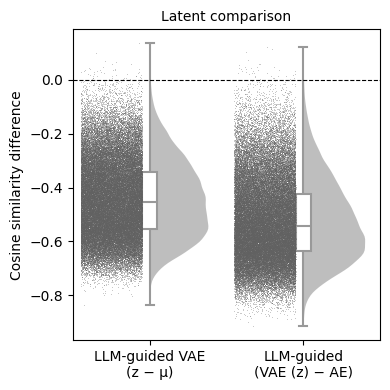

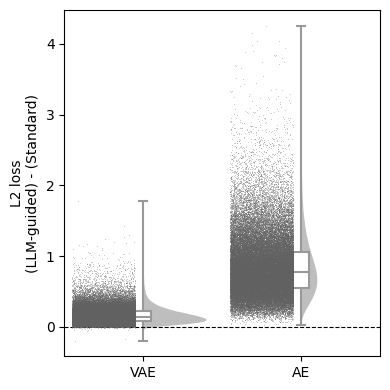

In [7]:
dict_models_alignment_data_path = {
    "Standard AE": "/workspace/data/checkpoints/vanilla_ae_loss_l2/cocoDoerig/run_0/evaluation/checkpoint_epoch50/alignment_data.json",
    "LLM-guided AE": "/workspace/data/checkpoints/ae_loss_l2/cocoDoerig/run_0/evaluation/checkpoint_epoch25/alignment_data.json",
    "Standard VAE": "/workspace/data/checkpoints/vanilla_from_ae_beta_vae_loss_standard_beta0.001_recon_loss_l2/cocoDoerig/run_0/evaluation/checkpoint_epoch50/alignment_data.json",
    "LLM-guided VAE": "/workspace/data/checkpoints/beta_vae_loss_llm_alignment_beta0.001_recon_loss_l2_llm_alignment_loss_cosine_similarity_gamma0.5/cocoDoerig/run_0/evaluation/checkpoint_epoch30/alignment_data.json"
}

cosine_similarity_array = []
model_names = []
recon_mse_loss_array = []
model_names_recon = []

for model_name, alignment_data_path in dict_models_alignment_data_path.items():
    with open(alignment_data_path, "r") as f:
        alignment_data = json.load(f)

    recon_mse_loss_array.append(alignment_data["reconstruction_mse_loss"])
    model_names_recon.append(model_name)

    if "VAE" in model_name:
        cosine_similarity_array.append(alignment_data["cosine_similarity"])
        model_names.append(f"{model_name} (latent)")
        cosine_similarity_array.append(alignment_data["cosine_similarity_mu"])
        model_names.append(f"{model_name} (mu)")
    else:
        cosine_similarity_array.append(alignment_data["cosine_similarity"])
        model_names.append(model_name)

cosine_similarity_array = np.array(cosine_similarity_array)
recon_mse_loss_array = np.array(recon_mse_loss_array)


# Fig 1: LLM-guided vs Standard (AE, VAE μ)
pf.plot_diff_raincloud(
    cosine_similarity_array, "cosine_similarity", model_names,
    "Cosine similarity\n(LLM-guided) - (Standard)",
    title=None,
    cosine_group="vs_standard",
    font_size=10,
)

# Fig 2: latent-space comparisons (z − μ, VAE(z) − AE)
pf.plot_diff_raincloud(
    cosine_similarity_array, "cosine_similarity", model_names,
    "Cosine similarity difference",
    title="Latent comparison",
    cosine_group="latent",
    font_size=10,
)

pf.plot_diff_raincloud(
    recon_mse_loss_array, "reconstruction_loss", model_names_recon,
    "L2 loss\n(LLM-guided) - (Standard)",
    title=None,
    font_size=10,
)

del cosine_similarity_array
del recon_mse_loss_array

## change in variance for VAE over training

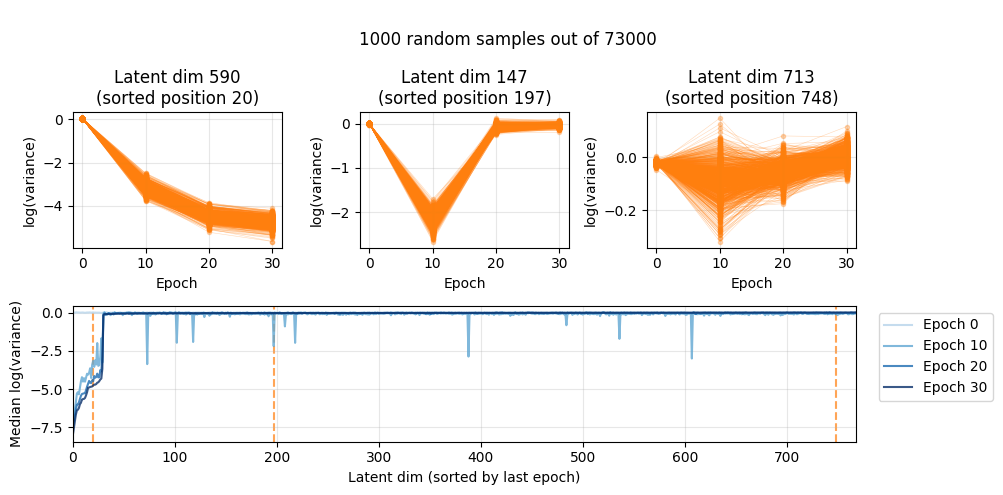

In [8]:
checkpoints = ["checkpoint_epoch0", "checkpoint_epoch10", "checkpoint_epoch20", "checkpoint_epoch30"]
log_var_dir_path = Path("/workspace/data/checkpoints/beta_vae_loss_llm_alignment_beta0.001_recon_loss_l2_llm_alignment_loss_cosine_similarity_gamma0.5/cocoDoerig/run_0/evaluation/")
log_var_median_across_samples_array = None

# keep some data for plots
n_samples_to_plot = 1000
example_pos = 20

for checkpoint in checkpoints:
    log_var_path = log_var_dir_path / checkpoint / "log_var.pt"
    log_var = torch.load(log_var_path, map_location="cpu").numpy()
    # initialize log_var_array if it's the first checkpoint
    if log_var_median_across_samples_array is None:
        n_samples, n_dims = log_var.shape
        log_var_median_across_samples_array = np.zeros((len(checkpoints), n_dims))
        # random samples for plot
        sample_idx = np.random.choice(n_samples, n_samples_to_plot, replace=False)
        log_var_rand_array = np.zeros((len(checkpoints), n_samples_to_plot, n_dims))    
                                          
    log_var_median_across_samples_array[checkpoints.index(checkpoint)] = np.median(log_var, axis=0)
    log_var_rand_array[checkpoints.index(checkpoint)] = log_var[sample_idx, :]

pf.plot_log_var_evolution(
    log_var_median_across_samples_array,
    log_var_rand_array,
    checkpoints,
    n_samples,
    n_dims,
    n_samples_to_plot,
    example_pos=example_pos,
)